In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go


In [3]:
minute_data = pd.read_csv('datasets/SPY-minute-aggregations(in).csv', parse_dates=['Timestamp'])

In [4]:
minute_data.head()

,Timestamp,Open,High,Low,Close,Volume
0,2020-10-19 08:00:00+00:00,348.60,348.93,348.60,348.93,16043
1,2020-10-19 08:01:00+00:00,348.98,349.12,348.98,349.05,6530
2,2020-10-19 08:02:00+00:00,349.09,349.09,349.07,349.07,1633
3,2020-10-19 08:05:00+00:00,348.85,348.85,348.85,348.85,250
4,2020-10-19 08:06:00+00:00,348.80,348.80,348.62,348.62,1749


In [5]:
fig = go.Figure(data=go.Scatter(x=minute_data[:1000]['Timestamp'], 
                                    y=minute_data[:1000]['Close'], 
                                    mode='lines'))
fig.update_layout(title='SPY Minute Close Prices')
fig.show()

In [6]:
def price_kinematics(df, price_col="Close", time_col="Timestamp"):
    """
    Computes time-aware derivatives and percent-change measures:
      d1   : first derivative (slope of price per second)
      d2   : second derivative (change in slope per second)
      pct  : percent change between points (return)
      dpct : change in percent change (Δ return)
    """
    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col], utc=True, errors="coerce")
    out = out.sort_values(time_col).reset_index(drop=True)

    # Δt in seconds (handle uneven spacing)
    dt = out[time_col].diff().dt.total_seconds()
    med_dt = np.nanmedian(dt)
    dt.iloc[0] = med_dt if np.isfinite(med_dt) and med_dt > 0 else 1.0

    # first derivative (slope)
    out["d1"] = out[price_col].diff() / dt

    # second derivative (change of slope)
    out["d2"] = out["d1"].diff() / dt

    # percent change between points (simple return)
    out["pct"] = out[price_col].pct_change()

    # change in percent change (Δ return)
    out["dpct"] = out["pct"].diff()

    # target: next period percent change
    out["target"] = (out[price_col].shift(-1) - out[price_col])/ out[price_col]

    return out

In [7]:
result = price_kinematics(minute_data, price_col="Close", time_col="Timestamp")
print(result.head(10))

                  Timestamp    Open    High     Low   Close  Volume        d1  \
0 2020-10-19 08:00:00+00:00  348.60  348.93  348.60  348.93   16043       NaN   
1 2020-10-19 08:01:00+00:00  348.98  349.12  348.98  349.05    6530  0.002000   
2 2020-10-19 08:02:00+00:00  349.09  349.09  349.07  349.07    1633  0.000333   
3 2020-10-19 08:05:00+00:00  348.85  348.85  348.85  348.85     250 -0.001222   
4 2020-10-19 08:06:00+00:00  348.80  348.80  348.62  348.62    1749 -0.003833   
5 2020-10-19 08:07:00+00:00  348.58  348.62  348.56  348.62    1872  0.000000   
6 2020-10-19 08:08:00+00:00  348.70  348.70  348.70  348.70     184  0.001333   
7 2020-10-19 08:09:00+00:00  348.73  348.73  348.72  348.72     200  0.000333   
8 2020-10-19 08:10:00+00:00  348.86  348.86  348.86  348.86     335  0.002333   
9 2020-10-19 08:11:00+00:00  348.84  348.84  348.84  348.84     356 -0.000333   

         d2       pct      dpct    target  
0       NaN       NaN       NaN  0.000344  
1       NaN  0.00034

/var/folders/5h/lv_gm99s337dww6tj437kv080000gn/T/ipykernel_4573/3291029830.py:16: SettingWithCopyWarning:

modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.



Pearson correlations:
               d1        d2       pct      dpct    target
d1      1.000000  0.725372  0.516603  0.380440 -0.023543
d2      0.725372  1.000000  0.372786  0.522873 -0.011766
pct     0.516603  0.372786  1.000000  0.711187 -0.011573
dpct    0.380440  0.522873  0.711187  1.000000 -0.005495
target -0.023543 -0.011766 -0.011573 -0.005495  1.000000

Spearman correlations:
               d1        d2       pct      dpct    target
d1      1.000000  0.667456  0.988840  0.658220 -0.020511
d2      0.667456  1.000000  0.657212  0.974282 -0.005107
pct     0.988840  0.657212  1.000000  0.669967 -0.020700
dpct    0.658220  0.974282  0.669967  1.000000 -0.005623
target -0.020511 -0.005107 -0.020700 -0.005623  1.000000


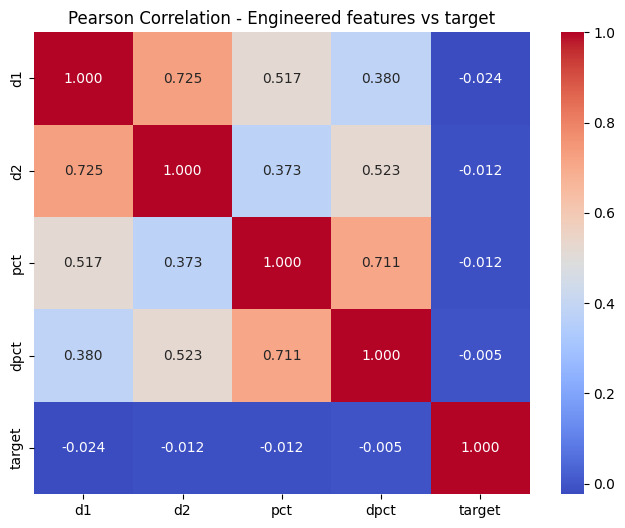

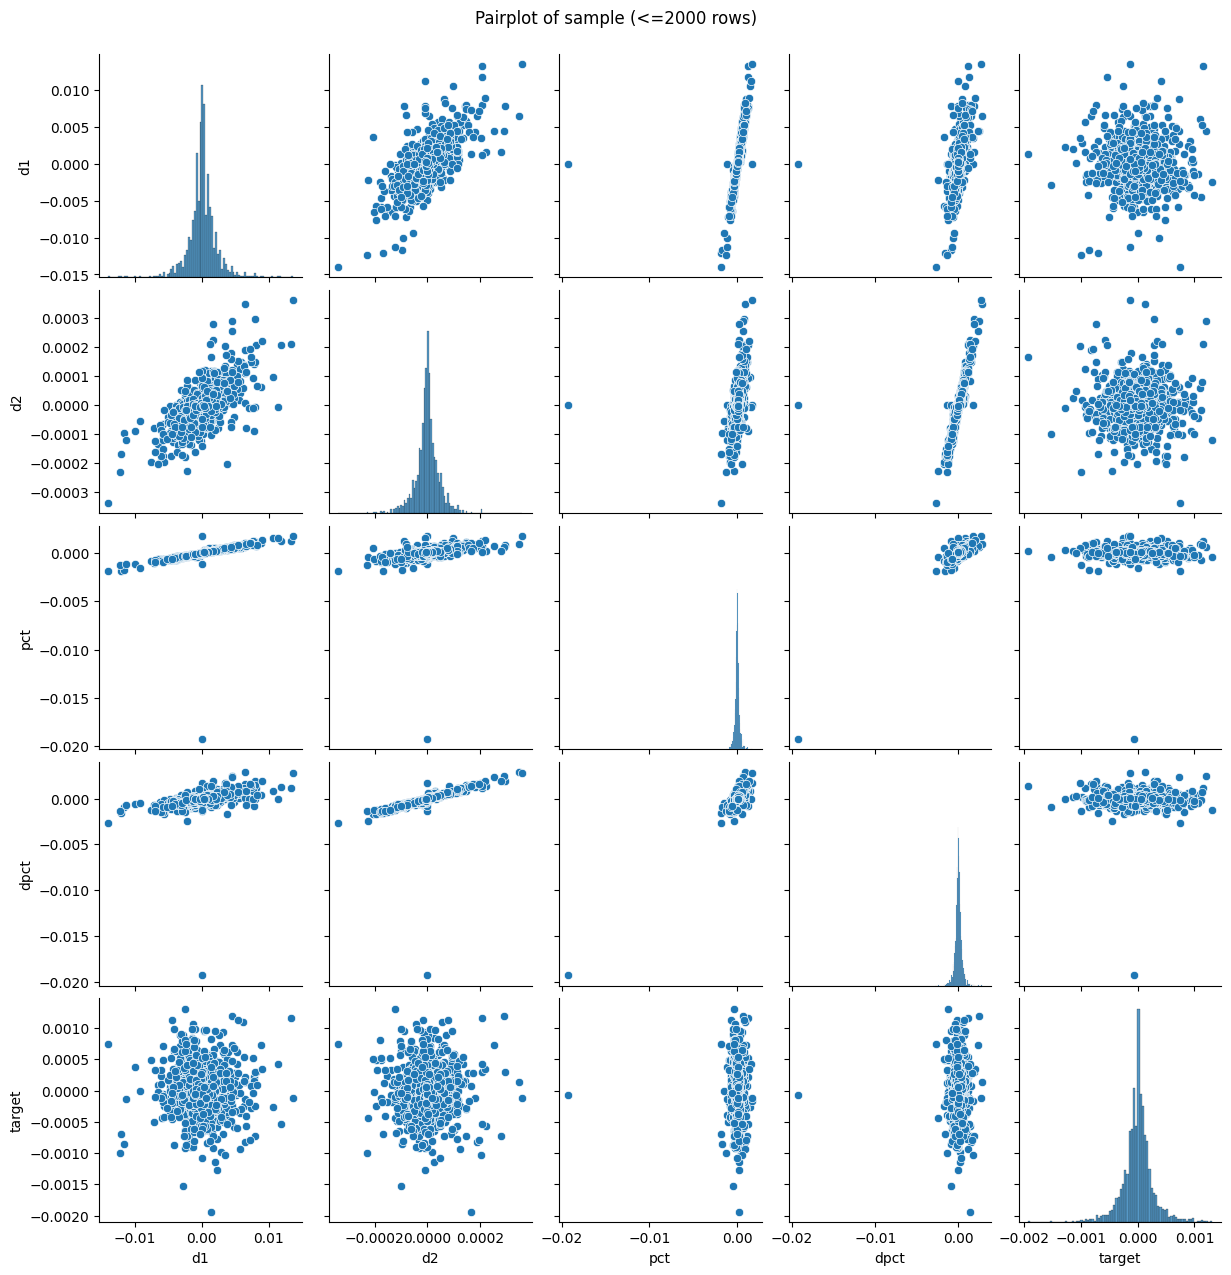

In [8]:


# ensure 'result' exists
cols = ['d1','d2','pct','dpct','target']
missing = [c for c in cols if c not in result.columns]
if missing:
    raise KeyError(f"Missing expected columns in result: {missing}")

# compute correlations (Pearson + Spearman)
corr_pearson = result[cols].corr(method='pearson')
corr_spearman = result[cols].corr(method='spearman')

print('Pearson correlations:\n', corr_pearson)
print('\nSpearman correlations:\n', corr_spearman)

# seaborn heatmap for Pearson
plt.figure(figsize=(8,6))
sns.heatmap(corr_pearson, annot=True, fmt='.3f', cmap='coolwarm')
plt.title('Pearson Correlation - Engineered features vs target')
plt.show()

# pairplot on a sample to avoid overplotting
sample = result[cols].dropna().sample(min(2000, len(result)))
sns.pairplot(sample)
plt.suptitle('Pairplot of sample (<=2000 rows)', y=1.02)
plt.show()

# interactive scatter matrix with plotly (sampled)
fig = px.scatter_matrix(sample, dimensions=['d1','d2','pct','dpct'], color=sample['target']>0, title='Scatter matrix (colored by target>0)')
fig.update_traces(diagonal_visible=False)
fig.show()

# scatter plots of each feature vs target
for f in ['d1','d2','pct','dpct']:
    fig = px.scatter(result.sample(min(2000, len(result))).dropna(), x=f, y='target', trendline='ols', title=f'{f} vs target')
    fig.show()

In [9]:
d1_error_range = result[(result['d1'] > -0.0001) & (result['d1'] < 0.0001)]

In [10]:
d1_error_range.head()

,Timestamp,Open,High,Low,Close,Volume,d1,d2,pct,dpct,target
5,2020-10-19 08:07:00+00:00,348.58,348.62,348.56,348.62,1872,0.0,0.000064,0.0,0.000659,0.000229
26,2020-10-19 08:36:00+00:00,349.07,349.09,349.05,349.09,2600,0.0,0.000003,0.0,0.000057,-0.000201
34,2020-10-19 08:50:00+00:00,349.18,349.19,349.18,349.18,1502,0.0,-0.000004,0.0,-0.000115,0.000143
45,2020-10-19 09:18:00+00:00,349.21,349.22,349.21,349.22,1653,0.0,0.000019,0.0,0.000200,0.000344
59,2020-10-19 09:39:00+00:00,349.16,349.16,349.16,349.16,410,0.0,0.000014,0.0,0.000143,0.000258


Total near-zero d1 points: 25986
Sign switches at near-zero points: 15374
Sample indices with sign switch: [5, 45, 59, 80, 84, 105, 111, 112, 123, 137]


In [57]:
e = 0.000001
d1 = result['d1']

near_zero_idx = result.index[d1.abs() <= e]
correct_switches = []
false_signals = []

for idx in near_zero_idx:
    if idx == 0 or idx == len(result)-1:
        continue
    before = result["pct"].iloc[idx-1]
    after = result["pct"].iloc[idx+1]
    if np.sign(before) != np.sign(after):
        correct_switches.append(idx)
    else:
        false_signals.append(idx)

In [58]:
print(f"Number of points with |d1| <= {e}: {len(near_zero_idx)}")
print(f"Correct sign switches around near-zero d1: {len(correct_switches)}")
print(f"False signals around near-zero d1: {len(false_signals)}")
print(f"Acurate sign switch rate: {len(correct_switches) / len(near_zero_idx) * 100:.2f}%")

Number of points with |d1| <= 1e-06: 17239
Correct sign switches around near-zero d1: 10438
False signals around near-zero d1: 6801
Acurate sign switch rate: 60.55%


In [60]:
# Set the time span to display (edit this variable)
display_range = (result['Timestamp'].iloc[0], result['Timestamp'].iloc[1000])  # Example: first 1000 points

mask = (result['Timestamp'] >= display_range[0]) & (result['Timestamp'] <= display_range[1])

# Find both correct and incorrect predictions


# Plot base price
fig = go.Figure()
fig.add_trace(go.Scatter(x=result.loc[mask, 'Timestamp'], 
                        y=result.loc[mask, 'Close'], 
                        mode='lines', 
                        name='Price'))

# Plot correct sign switches (red X)
correct_idx = [idx for idx in correct_switches if mask.iloc[idx]]
if correct_idx:
    fig.add_trace(go.Scatter(x=result['Timestamp'].iloc[correct_idx], 
                            y=result['Close'].iloc[correct_idx], 
                            mode='markers', 
                            name='Correct Sign Switch', 
                            marker=dict(color='red', size=10, symbol='x')))

# Plot false signals (green triangle)
false_idx = [idx for idx in false_signals if mask.iloc[idx]]
if false_idx:
    fig.add_trace(go.Scatter(x=result['Timestamp'].iloc[false_idx], 
                            y=result['Close'].iloc[false_idx], 
                            mode='markers', 
                            name='No Sign Switch', 
                            marker=dict(color='green', size=10, symbol='triangle-up')))

fig.update_layout(title=f'Price with Sign-Switch Analysis ({display_range[0]} to {display_range[1]})', 
                 xaxis_title='Timestamp', 
                 yaxis_title='Price',
                 plot_bgcolor='white')

fig.show()

print(f"In selected range:")
print(f"- Found {len(correct_idx)} correct sign switches (red X)")
print(f"- Found {len(false_idx)} points where d1≈0 but no sign switch (yellow triangle)")
print(f"Success rate: {len(correct_idx)/(len(correct_idx) + len(false_idx)):.1%}")

In selected range:
- Found 67 correct sign switches (red X)
- Found 20 points where d1≈0 but no sign switch (yellow triangle)
Success rate: 77.0%
